# Madrid Houses for Rent — Linear Regression Pipeline

Artifacts produced (same as `main.py`):
- `data/processed/clean.csv`
- `models/model.joblib`
- `reports/predictions.csv`


### A) Environment setup and imports

In [5]:

from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure we can import the local src/ package
def find_repo_root(start: Path, marker_dir: str = "src", max_hops: int = 12) -> Path:
    current = start.resolve()
    for _ in range(max_hops):
        if (current / marker_dir).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise RuntimeError(
        f"Could not find repo root containing '{marker_dir}/' starting from: {start}"
    )

PROJECT_ROOT = find_repo_root(Path.cwd())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: C:\Users\ricar\OneDrive\Documentos\0. Maestria\5. Term 2\MLOps\1-mlops-kickoff-repo


### B) Imports (same as `main.py`)

In [6]:

from sklearn.model_selection import train_test_split

from src.validate import validate_dataframe
from src.clean_data import clean_dataframe
from src.evaluate import evaluate_model
from src.features import get_feature_preprocessor
from src.infer import run_inference
from src.load_data import load_raw_data
from src.train import train_model
from src.utils import load_csv, save_csv, save_model, load_model

print("Imports OK")


Imports OK


### C) Sandbox configuration (SETTINGS)

In [7]:

SETTINGS = {
    "is_example_config": False,
    "problem_type": "regression",
    "random_state": 42,
    "test_size": 0.25,
    "target_column": "rent",
    "paths": {
        "raw_data": "data/raw/Houses_for_rent.csv",
        "processed_data": "data/processed/clean.csv",
        "model": "models/model.joblib",
        "predictions": "reports/predictions.csv",
        "inference": "data/inference/Houses_for_rent_inference.csv",
    },
    "features": {
        # Schema normalized to match the lowercase convention used by main.py
        "quantile_bin": [],
        "categorical_onehot": ["district"],
        "numeric_passthrough": [
            "sq.mt",
            "floor",
            "bedrooms",
            "outer",
            "duplex",
            "cottage",
            "elevator",
            "penthouse",
            "semidetached",
        ],
        "n_bins": 3,
    },
}

raw_path = PROJECT_ROOT / SETTINGS["paths"]["raw_data"]
processed_path = PROJECT_ROOT / SETTINGS["paths"]["processed_data"]
model_path = PROJECT_ROOT / SETTINGS["paths"]["model"]
preds_path = PROJECT_ROOT / SETTINGS["paths"]["predictions"]
inference_path = PROJECT_ROOT / SETTINGS["paths"]["inference"]

for p in [raw_path, processed_path, model_path, preds_path, inference_path]:
    p.parent.mkdir(parents=True, exist_ok=True)

raw_path, processed_path, model_path, preds_path, inference_path


(WindowsPath('C:/Users/ricar/OneDrive/Documentos/0. Maestria/5. Term 2/MLOps/1-mlops-kickoff-repo/data/raw/Houses_for_rent.csv'),
 WindowsPath('C:/Users/ricar/OneDrive/Documentos/0. Maestria/5. Term 2/MLOps/1-mlops-kickoff-repo/data/processed/clean.csv'),
 WindowsPath('C:/Users/ricar/OneDrive/Documentos/0. Maestria/5. Term 2/MLOps/1-mlops-kickoff-repo/models/model.joblib'),
 WindowsPath('C:/Users/ricar/OneDrive/Documentos/0. Maestria/5. Term 2/MLOps/1-mlops-kickoff-repo/reports/predictions.csv'),
 WindowsPath('C:/Users/ricar/OneDrive/Documentos/0. Maestria/5. Term 2/MLOps/1-mlops-kickoff-repo/data/inference/Houses_for_rent_inference.csv'))

### 1) Load raw data (`src.load_data`)

In [8]:

df_raw = load_raw_data(raw_path)
print("Raw shape:", df_raw.shape)
df_raw.head()


[load_data.load_raw_data] Loading raw data from: C:\Users\ricar\OneDrive\Documentos\0. Maestria\5. Term 2\MLOps\1-mlops-kickoff-repo\data\raw\Houses_for_rent.csv
[utils.load_csv] Loading CSV from: C:\Users\ricar\OneDrive\Documentos\0. Maestria\5. Term 2\MLOps\1-mlops-kickoff-repo\data\raw\Houses_for_rent.csv
[load_data.load_raw_data] Loaded shape=(2074, 16), columns=['Unnamed: 0', 'Id', 'District', 'Address', 'Number', 'Area', 'Rent', 'Bedrooms', 'Sq.Mt', 'Floor', 'Outer', 'Elevator', 'Penthouse', 'Cottage', 'Duplex', 'Semidetached']
Raw shape: (2074, 16)


,Unnamed: 0,Id,District,Address,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
0,0,1,Ciudad Lineal,Piso en Quintana,NaN,Quintana,1300,2.0,72,3.0,1.0,1.0,0,0,0,0
1,1,2,Ciudad Lineal,Piso en calle de Arturo Soria,NaN,Costillares,3000,5.0,260,2.0,1.0,1.0,0,0,0,0
2,2,3,Ciudad Lineal,Piso en calle de Vicente Muzas,4,Colina,1300,2.0,100,3.0,1.0,1.0,0,0,0,0
3,3,4,Ciudad Lineal,Piso en calle Badajoz,NaN,San Pascual,1600,3.0,120,4.0,1.0,1.0,0,0,0,0
4,4,5,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,9,Ventas,800,2.0,60,3.0,1.0,0.0,0,0,0,0


### 2) Focused EDA checks

Columns: ['Unnamed: 0', 'Id', 'District', 'Address', 'Number', 'Area', 'Rent', 'Bedrooms', 'Sq.Mt', 'Floor', 'Outer', 'Elevator', 'Penthouse', 'Cottage', 'Duplex', 'Semidetached']
Dtypes: Unnamed: 0        int64
Id                int64
District            str
Address             str
Number              str
Area                str
Rent              int64
Bedrooms        float64
Sq.Mt             int64
Floor           float64
Outer           float64
Elevator        float64
Penthouse         int64
Cottage           int64
Duplex            int64
Semidetached      int64
dtype: object
Missing values (top 15):


Number        1334
Outer          161
Floor          141
Elevator       133
Bedrooms        89
Area             4
Address          0
Unnamed: 0       0
Rent             0
Id               0
District         0
Sq.Mt            0
Penthouse        0
Cottage          0
Duplex           0
dtype: int64

Detected target: Rent


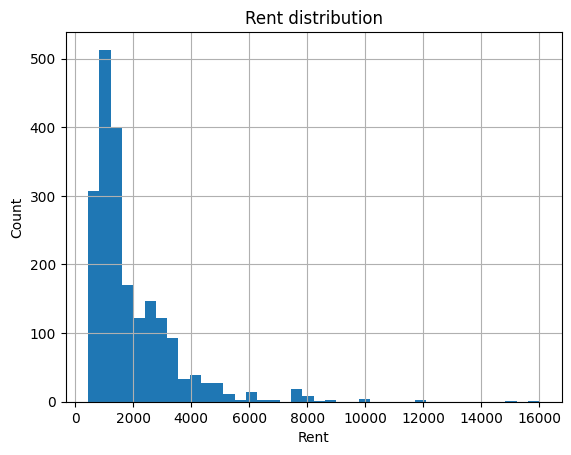

In [9]:

print("Columns:", list(df_raw.columns))
print("Dtypes:", df_raw.dtypes)

print("Missing values (top 15):")
display(df_raw.isna().sum().sort_values(ascending=False).head(15))

# Target distribution (supports either 'Rent' or 'rent')
found_target = "Rent" if "Rent" in df_raw.columns else ("rent" if "rent" in df_raw.columns else None)
print("Detected target:", found_target)

if found_target:
    plt.figure()
    pd.to_numeric(df_raw[found_target], errors="coerce").dropna().hist(bins=40)
    plt.title("Rent distribution")
    plt.xlabel("Rent")
    plt.ylabel("Count")
    plt.show()


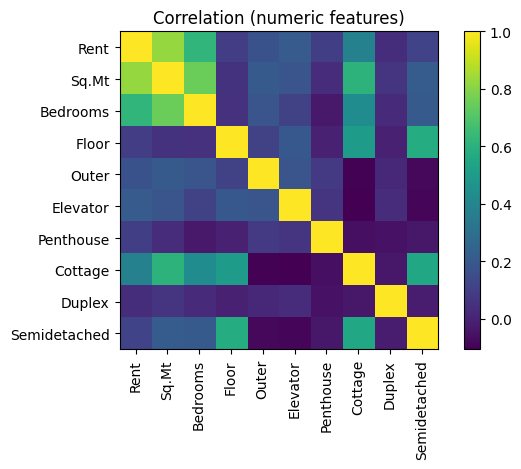

In [10]:

# Correlation heatmap for numeric columns that exist
num_candidates = [
    "Rent","Sq.Mt","Bedrooms","Floor","Outer","Elevator","Penthouse","Cottage","Duplex","Semidetached",
    "rent","sq.mt","bedrooms","floor","outer","elevator","penthouse","cottage","duplex","semidetached",
]
num_cols = [c for c in num_candidates if c in df_raw.columns]

if num_cols:
    df_num = df_raw[num_cols].apply(pd.to_numeric, errors="coerce")
    corr = df_num.corr(numeric_only=True)
    plt.figure()
    plt.imshow(corr.values)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation (numeric features)")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


In [11]:

# District summary (if present)
if "District" in df_raw.columns and found_target:
    tmp = df_raw[["District", found_target]].copy()
    tmp[found_target] = pd.to_numeric(tmp[found_target], errors="coerce")
    summary = tmp.groupby("District")[found_target].agg(["count","mean","median"]).sort_values("mean", ascending=False)
    display(summary.head(12))


,count,mean,median
District,,,
Moncloa,160,2785.306250,2300.0
Salamanca,311,2784.308682,2500.0
Retiro,80,2311.875000,1700.0
Hortaleza,117,2304.641026,1600.0
Chamartín,214,2158.682243,1737.5
Chamberí,195,2107.400000,1699.0
Centro,280,1821.300000,1450.0
Ciudad Lineal,99,1546.252525,1275.0
Fuencarral,111,1523.063063,1300.0


### 3) Clean data (`src.clean_data`)

In [12]:

target_column = SETTINGS["target_column"]
feature_cfg = SETTINGS["features"]

configured_feature_cols = (
    feature_cfg.get("quantile_bin", [])
    + feature_cfg.get("categorical_onehot", [])
    + feature_cfg.get("numeric_passthrough", [])
)
required_columns = list(dict.fromkeys(configured_feature_cols + [target_column]))

print("Required columns (normalized):")
required_columns


Required columns (normalized):


['district',
 'sq.mt',
 'floor',
 'bedrooms',
 'outer',
 'duplex',
 'cottage',
 'elevator',
 'penthouse',
 'semidetached',
 'rent']

In [13]:

df_clean = clean_dataframe(df_raw, target_column=target_column, required_columns=required_columns)
print("Clean shape:", df_clean.shape)
df_clean.head()


[clean_data.clean_dataframe] Cleaning raw dataframe (baseline = identity transform)
[clean_data.clean_dataframe] Dropped 0 rows with missing target
[clean_data.clean_dataframe] Normalized categorical column district
Clean shape: (1956, 12)


,index,district,rent,bedrooms,sq.mt,floor,outer,elevator,penthouse,cottage,duplex,semidetached
0,0,ciudad lineal,1300,2.0,72,3.0,1.0,1.0,0,0,0,0
1,1,ciudad lineal,3000,5.0,260,2.0,1.0,1.0,0,0,0,0
2,2,ciudad lineal,1300,2.0,100,3.0,1.0,1.0,0,0,0,0
3,3,ciudad lineal,1600,3.0,120,4.0,1.0,1.0,0,0,0,0
4,4,ciudad lineal,800,2.0,60,3.0,1.0,0.0,0,0,0,0


### 4) Didactic check: what changed after cleaning

In [14]:

raw_norm = df_raw.rename(columns=lambda c: {
    "Rent":"rent","Sq.Mt":"sq.mt","Bedrooms":"bedrooms","Floor":"floor","District":"district",
    "Outer":"outer","Duplex":"duplex","Cottage":"cottage","Elevator":"elevator","Penthouse":"penthouse","Semidetached":"semidetached",
}.get(c, c))

comparison = pd.DataFrame({
    "raw_missing": raw_norm[required_columns].isna().sum(),
    "clean_missing": df_clean[required_columns].isna().sum(),
}).sort_values("raw_missing", ascending=False)

display(comparison.head(15))


,raw_missing,clean_missing
outer,161,156
floor,141,136
elevator,133,128
bedrooms,89,84
district,0,0
sq.mt,0,0
duplex,0,0
cottage,0,0
penthouse,0,0
semidetached,0,0


### 5) Validate data (security gate)

In [15]:

validate_dataframe(df_clean, required_columns=required_columns)
print("Validation OK")


[validate.validate_dataframe] Validating dataframe (fail fast checks)
Validation OK


### 6) Save processed CSV (artifact requirement)

In [16]:

save_csv(df_clean, processed_path)
print("Saved:", processed_path)


[utils.save_csv] Saving CSV to: C:\Users\ricar\OneDrive\Documentos\0. Maestria\5. Term 2\MLOps\1-mlops-kickoff-repo\data\processed\clean.csv
Saved: C:\Users\ricar\OneDrive\Documentos\0. Maestria\5. Term 2\MLOps\1-mlops-kickoff-repo\data\processed\clean.csv


### 7) Train/test split (leakage prevention)

In [17]:

X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=SETTINGS["test_size"],
    random_state=SETTINGS["random_state"],
    stratify=None,
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (1467, 11) Test: (489, 11)


### 8) Build the feature recipe (`src.features`)

In [18]:

# Fail-fast feature checks (mirrors main.py)
missing_cols = [c for c in configured_feature_cols if c not in X_train.columns]
if missing_cols:
    raise ValueError(
        f"Feature config error: these configured feature columns are missing from X_train: {missing_cols}. "
        "Update SETTINGS['features'] to match your dataset."
    )

preprocessor = get_feature_preprocessor(
    bin_cols=feature_cfg.get("quantile_bin", []),
    categorical_cols=feature_cfg.get("categorical_onehot", []),
    numeric_cols=feature_cfg.get("numeric_passthrough", []),
    n_bins=int(feature_cfg.get("n_bins", 3)),
)

preprocessor


[features.get_feature_preprocessor] Building ColumnTransformer feature recipe


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_onehot', ...), ('numeric_scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` an

### 9) Train (`src.train`)

In [19]:

model = train_model(
    X_train=X_train,
    y_train=y_train,
    preprocessor=preprocessor,
    problem_type=SETTINGS["problem_type"],
)

model


[train.train_model] Training model for problem_type=regression


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_onehot', ...), ('numeric_scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

### 10) Save model (artifact requirement)

In [20]:

save_model(model, model_path)
print("Saved:", model_path)


[utils.save_model] Saving model to: C:\Users\ricar\OneDrive\Documentos\0. Maestria\5. Term 2\MLOps\1-mlops-kickoff-repo\models\model.joblib
Saved: C:\Users\ricar\OneDrive\Documentos\0. Maestria\5. Term 2\MLOps\1-mlops-kickoff-repo\models\model.joblib


### 11) Evaluate (`src.evaluate`)

In [21]:

rmse = evaluate_model(model=model, X_test=X_test, y_test=y_test, problem_type=SETTINGS["problem_type"])
print("Held-out RMSE:", rmse)


Held-out RMSE: {'mae': 435.13875508285923, 'rmse': 738.3196577215789, 'r2': 0.790265295055457}


### 12) Inference demo (`src.infer`)

In [24]:

# Use an inference CSV if present; otherwise create one from X_test
if inference_path.exists():
    df_infer_raw = load_csv(inference_path)
else:
    df_infer_raw = X_test.sample(n=min(50, len(X_test)), random_state=SETTINGS["random_state"]).copy()
    df_infer_raw.to_csv(inference_path, index=False)

df_infer_clean = clean_dataframe(df_raw=df_infer_raw, target_column=target_column, required_columns=required_columns)
X_infer = df_infer_clean.drop(columns=[target_column])

df_pred = run_inference(model=model, X_infer=X_infer)
display(df_pred.head())

save_csv(df_pred, preds_path)
print("Saved:", preds_path)


[utils.load_csv] Loading CSV from: C:\Users\ricar\OneDrive\Documentos\0. Maestria\5. Term 2\MLOps\1-mlops-kickoff-repo\data\inference\Houses_for_rent_inference.csv
[clean_data.clean_dataframe] Cleaning raw dataframe (baseline = identity transform)
[clean_data.clean_dataframe] Dropped 0 rows with missing target
[clean_data.clean_dataframe] Normalized categorical column district
[infer.run_inference] Running inference
[infer.run_inference] Predictions
     prediction
0    757.849365
1   1957.000315
2   3889.933841
3    368.200377
4   2192.895066
5    971.474674
6   1699.633601
7    645.044156
8   2482.471266
9   3803.145990
10  2071.818503
11  1439.003955
12  1362.011878
13  2273.940442
14  1120.158557


,prediction
0,757.849365
1,1957.000315
2,3889.933841
3,368.200377
4,2192.895066


[utils.save_csv] Saving CSV to: C:\Users\ricar\OneDrive\Documentos\0. Maestria\5. Term 2\MLOps\1-mlops-kickoff-repo\reports\predictions.csv
Saved: C:\Users\ricar\OneDrive\Documentos\0. Maestria\5. Term 2\MLOps\1-mlops-kickoff-repo\reports\predictions.csv


### 13) Optional: Under/Fair/Over priced labeling (didactic)

In [25]:

y_pred = model.predict(X_test)
results = X_test.copy()
results["rent_predicted"] = y_pred
results["rent"] = y_test.values

rel_err = (results["rent"] - results["rent_predicted"]) / results["rent_predicted"]
results["classification"] = np.where(
    rel_err > 0.05, "Overpriced",
    np.where(rel_err > -0.05, "Fair priced", "Underpriced"),
)

results[["rent", "rent_predicted", "classification"]].head(10)


,rent,rent_predicted,classification
1360,3100,2942.998037,Overpriced
1703,700,535.740340,Overpriced
1146,1500,1730.730575,Underpriced
1758,740,981.679216,Underpriced
374,3700,2382.115515,Overpriced
1619,1100,1428.393640,Underpriced
1112,7500,6739.819415,Overpriced
1423,5990,4012.696740,Overpriced
1692,600,711.929414,Underpriced
307,1000,788.165797,Overpriced


### 14) Inspect saved artifacts

In [26]:

clean_from_disk = pd.read_csv(processed_path)
preds_from_disk = pd.read_csv(preds_path)
model_from_disk = load_model(model_path)

print("clean.csv shape:", clean_from_disk.shape)
print("predictions.csv shape:", preds_from_disk.shape)
print("model type:", type(model_from_disk))

display(clean_from_disk.head())
display(preds_from_disk.head())


[utils.load_model] Loading model from: C:\Users\ricar\OneDrive\Documentos\0. Maestria\5. Term 2\MLOps\1-mlops-kickoff-repo\models\model.joblib
clean.csv shape: (1956, 12)
predictions.csv shape: (15, 1)
model type: <class 'sklearn.pipeline.Pipeline'>


,index,district,rent,bedrooms,sq.mt,floor,outer,elevator,penthouse,cottage,duplex,semidetached
0,0,ciudad lineal,1300,2.0,72,3.0,1.0,1.0,0,0,0,0
1,1,ciudad lineal,3000,5.0,260,2.0,1.0,1.0,0,0,0,0
2,2,ciudad lineal,1300,2.0,100,3.0,1.0,1.0,0,0,0,0
3,3,ciudad lineal,1600,3.0,120,4.0,1.0,1.0,0,0,0,0
4,4,ciudad lineal,800,2.0,60,3.0,1.0,0.0,0,0,0,0


,prediction
0,757.849365
1,1957.000315
2,3889.933841
3,368.200377
4,2192.895066
